<a href="https://colab.research.google.com/github/pranay3995/preprocessing-neuro/blob/main/image_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow for image preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ============================================
# CELL 2: UPLOAD DATASET ZIP
# ============================================

from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving Bananadatset.zip.zip to Bananadatset.zip.zip
Dataset uploaded successfully!


In [3]:
# ============================================
# CELL 3: EXTRACT ZIP FILE
# ============================================

import zipfile
import os #allows us to work with file and file paths

zip_file = list(uploaded.keys())[0]

extract_path = "/content/pepper_dataset" # Changed this line to specify a directory

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:")
print(extract_path)

Dataset extracted to:
/content/pepper_dataset


In [4]:
# ============================================
# CELL 4: CHECK DATASET FOLDERS
# ============================================

for root, dirs, files_list in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

pepper_dataset/
  Bananadataset/


In [5]:
# ============================================
# CELL 5: FIND ALL IMAGE FILES
# ============================================

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

image_paths = []

for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

# Display first 10 image paths
for path in image_paths[:10]:
    print(path)

Total images found: 10
/content/pepper_dataset/Bananadataset/0890bcbd-rotated_by_60_Screen_Shot_2018-06-12_at_9.51.36_PM.png
/content/pepper_dataset/Bananadataset/001a4082-rotated_by_15_Screen_Shot_2018-06-12_at_8.53.29_PM.png
/content/pepper_dataset/Bananadataset/06cc8c47-rotated_by_45_Screen_Shot_2018-06-12_at_9.09.09_PM.png
/content/pepper_dataset/Bananadataset/00632ee1-rotated_by_30_Screen_Shot_2018-06-12_at_9.41.57_PM.png
/content/pepper_dataset/Bananadataset/01422f22-rotated_by_45_Screen_Shot_2018-06-12_at_10.05.07_PM (1).png
/content/pepper_dataset/Bananadataset/0141100d-rotated_by_75_Screen_Shot_2018-06-12_at_8.50.54_PM (1).png
/content/pepper_dataset/Bananadataset/07203c68-rotated_by_60_Screen_Shot_2018-06-12_at_9.25.00_PM.png
/content/pepper_dataset/Bananadataset/013cc786-rotated_by_75_Screen_Shot_2018-06-12_at_9.01.26_PM.png
/content/pepper_dataset/Bananadataset/06cc8c47-rotated_by_45_Screen_Shot_2018-06-12_at_9.09.09_PM (1).png
/content/pepper_dataset/Bananadataset/03584c38

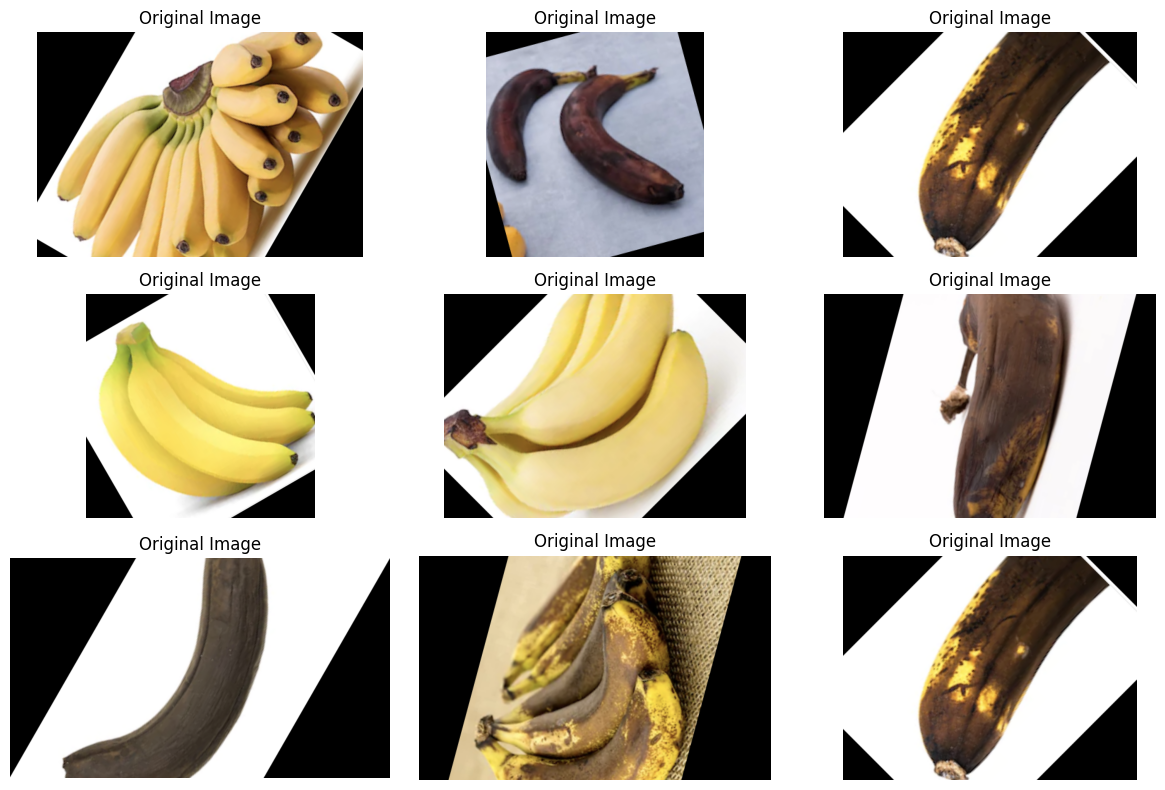

In [6]:
# ============================================
# CELL 6: DISPLAY ORIGINAL IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for i in range(min(9, len(image_paths))):
    img = Image.open(image_paths[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# ============================================
# CELL 7: CHECK IMAGE DIMENSIONS
# ============================================

sizes = []

for path in image_paths:
    try:
        img = Image.open(path)
        sizes.append(img.size)
    except:
        pass

print("Number of valid images:", len(sizes))

print("\nFirst 20 image sizes:")

for size in sizes[:20]:
    print(size)

Number of valid images: 10

First 20 image sizes:
(682, 470)
(306, 316)
(466, 356)
(486, 478)
(478, 356)
(632, 428)
(684, 396)
(576, 368)
(466, 356)
(492, 470)


In [8]:
# ============================================
# CELL 8: RESIZE IMAGES
# ============================================

IMG_SIZE = (224, 224)

resized_images = []

for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")

        # Resize image
        img_resized = img.resize(IMG_SIZE)

        resized_images.append(np.array(img_resized))

    except Exception as e:
        print("Error:", path, e)

resized_images = np.array(resized_images)

print("Resized dataset shape:")
print(resized_images.shape)

Resized dataset shape:
(10, 224, 224, 3)


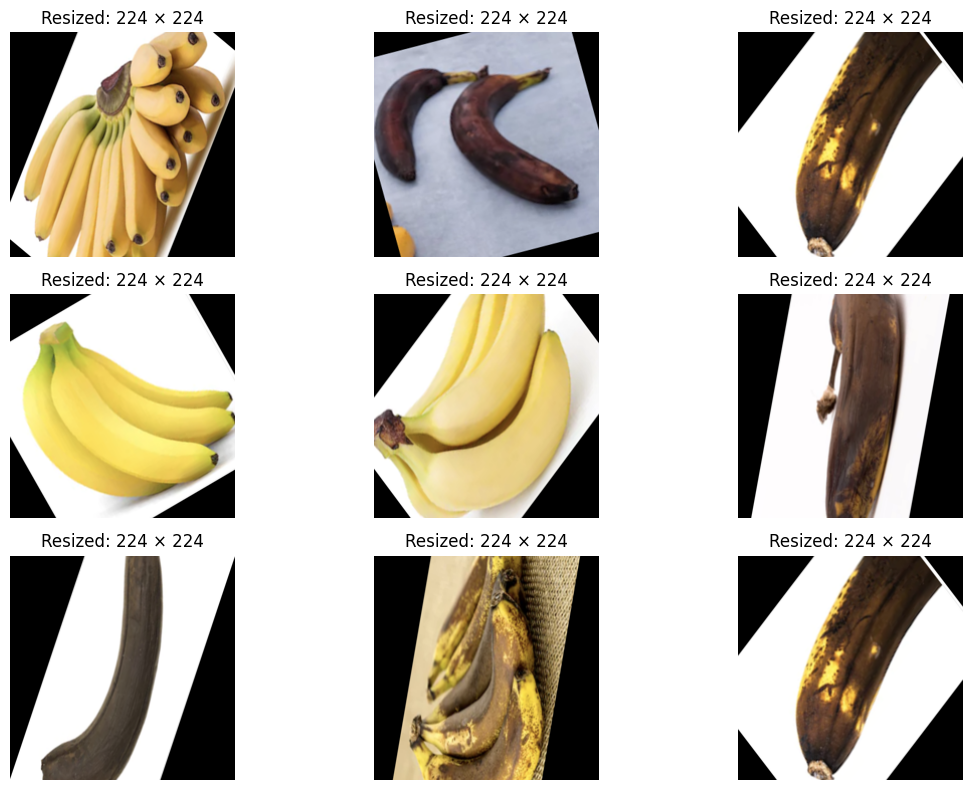

In [9]:
# ============================================
# CELL 9: DISPLAY RESIZED IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for i in range(min(9, len(resized_images))):

    plt.subplot(3, 3, i + 1)
    plt.imshow(resized_images[i])
    plt.title("Resized: 224 × 224")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# CELL 10: CONVERT TO FLOAT
# ============================================

resized_images = resized_images.astype("float32")

print("Data type:", resized_images.dtype)

print("Minimum pixel value:", resized_images.min())
print("Maximum pixel value:", resized_images.max())

Data type: float32
Minimum pixel value: 0.0
Maximum pixel value: 255.0


In [11]:
# ============================================
# CELL 11: NORMALIZATION
# ============================================

normalized_images = resized_images / 255.0

print("Minimum value:", normalized_images.min())
print("Maximum value:", normalized_images.max())

Minimum value: 0.0
Maximum value: 1.0


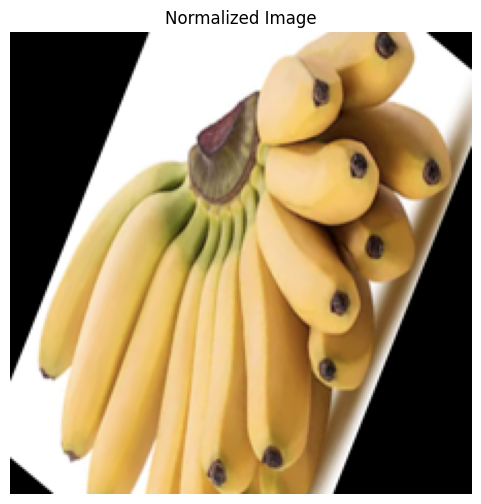

In [12]:
# ============================================
# CELL 12: DISPLAY NORMALIZED IMAGE
# ============================================

plt.figure(figsize=(6, 6))

plt.imshow(normalized_images[0])
plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [13]:
# ============================================
# CELL 13: CHECK FOR CORRUPTED IMAGES
# ============================================

valid_images = []
corrupted_images = []

for path in image_paths:

    try:
        img = Image.open(path)
        img.verify()
        valid_images.append(path)

    except:
        corrupted_images.append(path)

print("Valid images:", len(valid_images))
print("Corrupted images:", len(corrupted_images))

if len(corrupted_images) > 0:
    print("\nCorrupted images:")
    for path in corrupted_images:
        print(path)

Valid images: 10
Corrupted images: 0


In [14]:
# ============================================
# CELL 14: DATA AUGMENTATION
# ============================================

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

print("Data augmentation created successfully!")

Data augmentation created successfully!


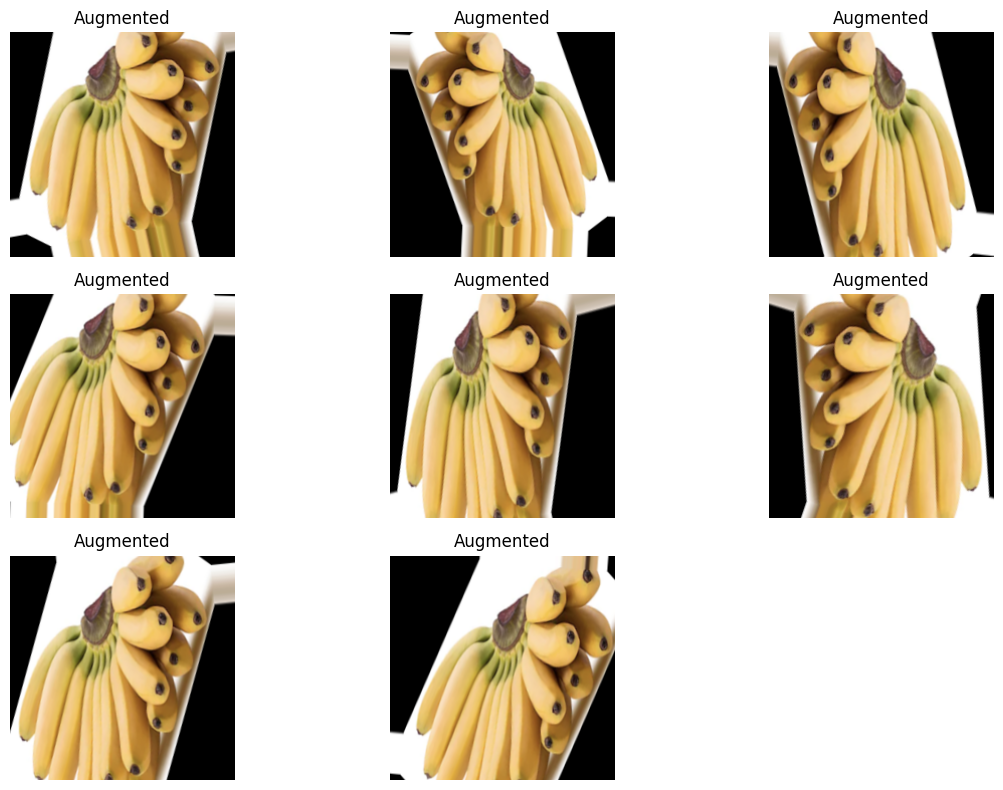

In [19]:
# ============================================
# CELL 15: VISUALIZE AUGMENTED IMAGES
# ============================================

sample_image = resized_images[0]

# Add batch dimension
sample_image = np.expand_dims(sample_image, axis=0)

augmented_images = datagen.flow(
    sample_image,
    batch_size=1
)

plt.figure(figsize=(12, 8))

for i in range(8):

    augmented_image = next(augmented_images)[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image.astype("uint8"))
    plt.title("Augmented")
    plt.axis("off")
#https://github.com/pranay3995/preprocessing-neuro-.git
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# CELL 17: LOAD DATASET USING TENSORFLOW
# ============================================

DATASET_DIR = extract_path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:")
print(train_dataset.class_names)

Found 10 files belonging to 1 classes.
Using 8 files for training.
Found 10 files belonging to 1 classes.
Using 2 files for validation.
Classes:
['Bananadataset']


In [17]:
# ============================================
# CELL 18: NORMALIZATION LAYER
# ============================================

normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

normalized_train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

normalized_validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed.")

Normalization completed.


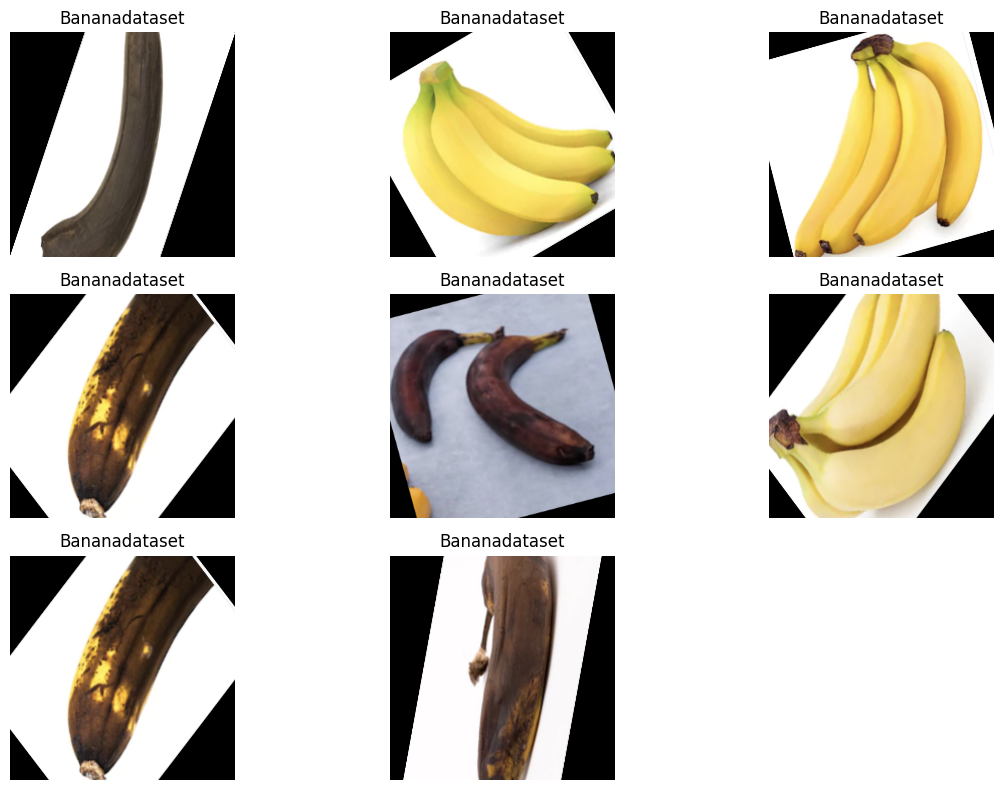

In [18]:
# ============================================
# CELL 19: DISPLAY FINAL PREPROCESSED IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for images, labels in normalized_train_dataset.take(1):

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()